In [3]:
# WE ARE FINDING OUT WHETHER THE PERSON IS TELLING HIS ACTUAL SALARY OR JUST BLUFFING
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
dataset = pd.read_csv('/content/Position_Salaries.csv')

In [5]:
x = dataset.iloc[ : , 1:-1].values
y = dataset.iloc[ : , -1].values

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x,y)

LinearRegression()


**So first, we will make a matrix of the features i.e. x1, square(x1), cube(x1),....., Nth time(x1) and we will call this matrix "poly".**

**the actual regressor will be the combination of poly_reg and the linear classifier and we will call it poly_reg2**


In [7]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg =  PolynomialFeatures(degree = 4)
# degree here means the value of 'n' in the formula of Polynomial regression
x_poly = poly_reg.fit_transform(x)

# Now we need to create a new linear regressor which can be trained on the new X values
# i.e. x_poly as it contains x1 , sq(x1) , cube(x1) etc.
# the old regressor is trained on the old values of X and not on x_poly.
lin_reg2 = LinearRegression()
lin_reg2.fit(x_poly,y)

LinearRegression()

**now, we have created a model with features, y = bo + b1x1 + b2(x1)^2 as the degree we have taken is 2.**

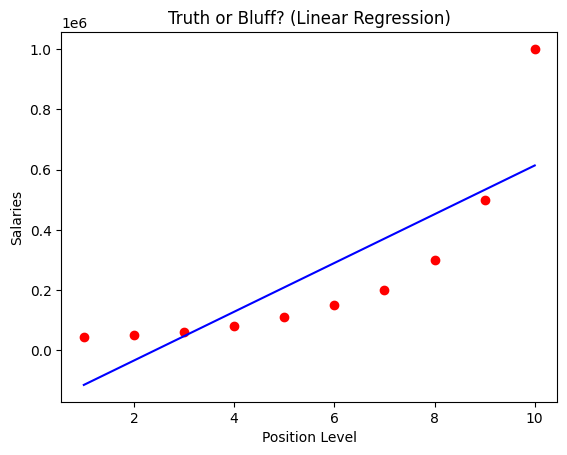

In [8]:
# VISUALIZING LINEAR REGRESSION RESULTS
plt.scatter(x,y, color = 'red') # plotting the actual dataset
plt.plot(x, lin_reg.predict(x),color = 'blue') # plotting dataset with predicted salaries
plt.title('Truth or Bluff? (Linear Regression)') # giving title to the visualization
plt.xlabel('Position Level')
plt.ylabel('Salaries')
plt.show()

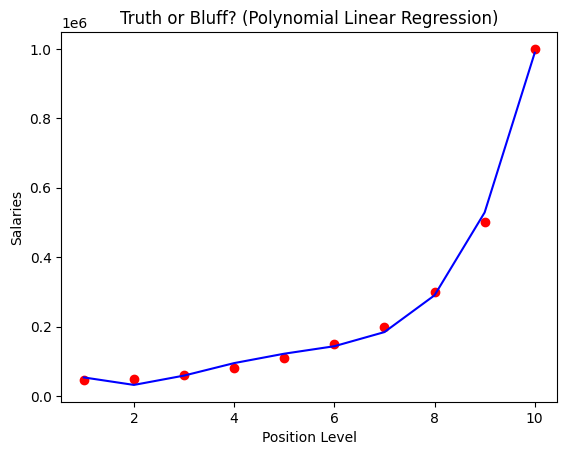

In [9]:
# VISUALIZING POLYNOMIAL LINEAR REGRESSION RESULTS
plt.scatter(x,y, color = 'red') # plotting the actual dataset
plt.plot(x, lin_reg2.predict(poly_reg.fit_transform(x)),color = 'blue') # plotting dataset with predicted salaries
plt.title('Truth or Bluff? (Polynomial Linear Regression)') # giving title to the visualization
plt.xlabel('Position Level')
plt.ylabel('Salaries')
plt.show()

In [10]:
# PREDICTING RESULTS WITH LINEAR REGRESSION
lin_reg.predict([[6.5]])

array([330378.78787879])

Here, you can see that the salary mentioned by this person(6.5) is somewhere 160k from the dataset but the salary predited by the **linear regression model** is 330k which is **very wrong prediction!**

In [11]:
# PREDICTING RESULTS WITH POLYNOMIAL REGRESSION
lin_reg2.predict(poly_reg.fit_transform([[6.5]]))

array([158862.45265155])

Here, we can see that the actual salary of person is 160K and the value predicted by **polynomial linear regression model** is 159K which is **near to the actual salary** as compared to the value predicted by simple linear regression model.